In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)


In [2]:
from pandas.api.types import is_numeric_dtype, is_integer_dtype, is_float_dtype

# Path to your raw data
file_path = '../data/raw/vehicles.csv'

def reduce_memory_usage(df):
    """
    Safely iterates through all columns of a dataframe and modifies the data type
    to reduce memory usage using strict type checking.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    
    for col in df.columns:
        # Strictly optimize Numerical Columns only
        if is_numeric_dtype(df[col]):
            c_min, c_max = df[col].min(), df[col].max()
            
            # Check if integer
            if is_integer_dtype(df[col]):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            
            # Check if float
            elif is_float_dtype(df[col]):
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
                    
        # Optimize Categorical (Object/String) Columns
        else:
            num_unique_values = len(df[col].unique())
            num_total_values = len(df[col])
            # If unique values are less than 50% of total data, convert to category
            if num_unique_values / num_total_values < 0.5:
                df[col] = df[col].astype('category')
                
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory reduced from {start_mem:.2f} MB to {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    
    return df

# Load data in chunks to prevent RAM crash
chunk_size = 100000 
chunks = []

print("Loading data in chunks... please wait.")
# Added on_bad_lines='skip' & low_memory=False to bypass malformed rows in messy CSVs
for chunk in pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip', low_memory=False):
    optimized_chunk = reduce_memory_usage(chunk)
    chunks.append(optimized_chunk)

# Combine all chunks into one DataFrame
df = pd.concat(chunks, axis=0, ignore_index=True)
print("\n--- Final Dataset Loaded Successfully! ---")

print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
display(df.head())


Loading data in chunks... please wait.
Memory reduced from 19.84 MB to 9.74 MB (50.9% reduction)
Memory reduced from 19.84 MB to 9.34 MB (52.9% reduction)
Memory reduced from 19.84 MB to 9.51 MB (52.1% reduction)
Memory reduced from 19.84 MB to 9.73 MB (51.0% reduction)
Memory reduced from 5.33 MB to 2.53 MB (52.5% reduction)

--- Final Dataset Loaded Successfully! ---
Total Rows: 426880, Total Columns: 26


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [3]:
def generate_health_report(dataframe):
    """
    Generates a health report for a given dataframe.
    """
    print("Generating Data Health Report...\n")
    
    # Missing values count
    missing_count = dataframe.isnull().sum()
    
    # Missing values percentage
    missing_percentage = (missing_count/len(dataframe)) * 100
    
    # Data types of columns
    data_types = dataframe.dtypes
    
    # Count of unique values in each column
    unique_values = dataframe.nunique()
    
    health_df = pd.DataFrame({
        'Data Type': data_types,
        'Missing Values': missing_count,
        'Missing %': missing_percentage.round(2),
        'Unique Values': unique_values
    })
    
    health_df = health_df.sort_values(by='Missing %', ascending=False)
    
    return health_df

# Generate Report and Displaying
health_report = generate_health_report(df)
display(health_report)


Generating Data Health Report...



,Data Type,Missing Values,Missing %,Unique Values
county,float64,426880,100.00,0
size,category,306361,71.77,4
cylinders,category,177678,41.62,8
condition,category,174104,40.79,6
VIN,object,161042,37.73,118264
drive,category,130567,30.59,3
paint_color,category,130203,30.50,12
type,category,92858,21.75,13
manufacturer,object,17646,4.13,42
title_status,category,8242,1.93,6


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   id            426880 non-null  int64   
 1   url           426880 non-null  object  
 2   region        426880 non-null  object  
 3   region_url    426880 non-null  object  
 4   price         426880 non-null  int64   
 5   year          425675 non-null  float16 
 6   manufacturer  409234 non-null  object  
 7   model         421603 non-null  object  
 8   condition     252776 non-null  category
 9   cylinders     249202 non-null  category
 10  fuel          423867 non-null  category
 11  odometer      422480 non-null  float32 
 12  title_status  418638 non-null  category
 13  transmission  424324 non-null  category
 14  VIN           265838 non-null  object  
 15  drive         296313 non-null  category
 16  size          120519 non-null  category
 17  type          334022 non-null

In [5]:
# Drop useless identifiers and 100% missing columns
cols_to_drop = ['county','id', 'url', 'region_url', 'VIN', 'image_url', 'description']
df_cleaned = df.drop(columns=cols_to_drop)

print(f"Shape after dropping useless columns: {df_cleaned.shape}")

# X-Ray of the Target Variable (Price) BEFORE cleaning
print("\n--- Price Statistics BEFORE Outlier Removal ---")
print(df_cleaned['price'].describe().apply(lambda x: format(x, '.2f')))


Shape after dropping useless columns: (426880, 19)

--- Price Statistics BEFORE Outlier Removal ---
count        426880.00
mean          75199.03
std        12182282.17
min               0.00
25%            5900.00
50%           13950.00
75%           26485.75
max      3736928711.00
Name: price, dtype: object


In [6]:
# Removing Extreme Price Outliers
# Logic: Normal used car sells $500 - $1,50,000
lower_bound = 500
upper_bound = 150000
df_cleaned = df_cleaned[(df_cleaned['price'] >= lower_bound) & (df_cleaned['price'] <= upper_bound)]

print("\n--- Price Statistics AFTER Outlier Removal ---")
print(df_cleaned['price'].describe().apply(lambda x: format(x, '.2f')))

print(f"\nTotal rows remaining after target cleaning: {df_cleaned.shape[0]}")



--- Price Statistics AFTER Outlier Removal ---
count    384590.00
mean      19284.19
std       14842.55
min         500.00
25%        7800.00
50%       15900.00
75%       27990.00
max      150000.00
Name: price, dtype: object

Total rows remaining after target cleaning: 384590


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


Preparing Data for Extreme Visualization...


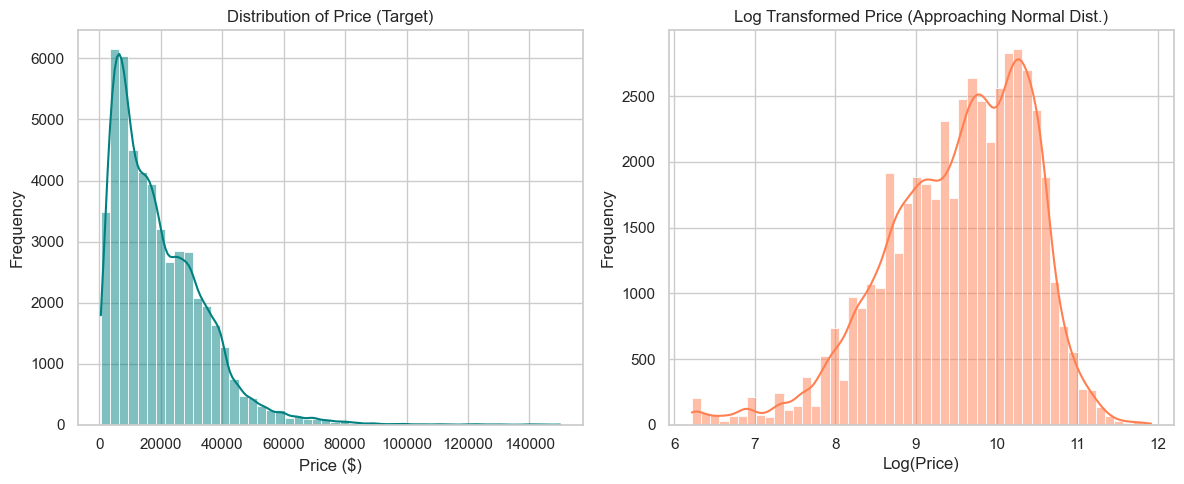

In [8]:
# Set extreme professional styling
plt.style.use('dark_background')
sns.set_theme(style="whitegrid", palette='muted')
plt.rcParams.update({'figure.max_open_warning':0})

print("Preparing Data for Extreme Visualization...")

sample_df = df_cleaned.sample(n=min(50000, len(df_cleaned)), random_state=42)

# SHAPE OF DATA: The Target Variable (Price)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(sample_df['price'], bins=50, kde=True, color='teal')
plt.title('Distribution of Price (Target)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
# Log transformation applying directly on plot to see if it fixes right-skewness
sns.histplot(np.log1p(sample_df['price']), bins=50, kde=True, color='coral')
plt.title('Log Transformed Price (Approaching Normal Dist.)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


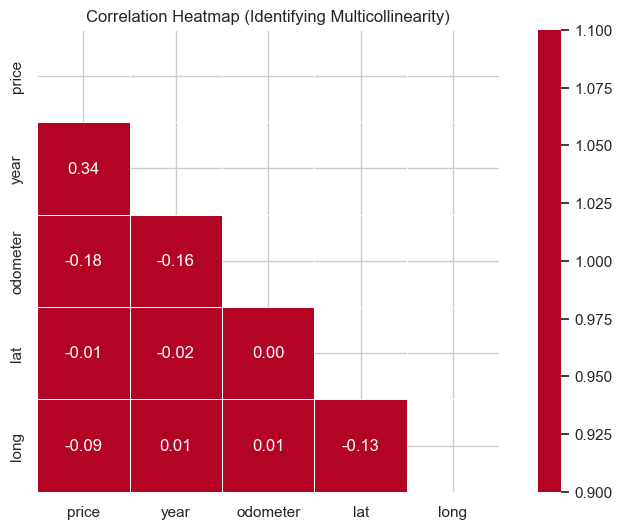

In [9]:
# 2. RELATIONSHIPS: Correlation Heatmap (Multicollinearity check)
num_cols = sample_df.select_dtypes(include=[np.number]).columns
corr_matrix = sample_df[num_cols].corr()

plt.figure(figsize=(10,6))
# Using extreme masking to hide upper triangle (cleaner look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmax=1, vmin=1, center=0, square=True, linewidths=.5)
plt.title('Correlation Heatmap (Identifying Multicollinearity)')
plt.show()


In [10]:
sample_df['condition'].unique()


[NaN, 'good', 'excellent', 'like new', 'fair', 'salvage', 'new']
Categories (6, object): ['excellent', 'fair', 'good', 'like new', 'new', 'salvage']

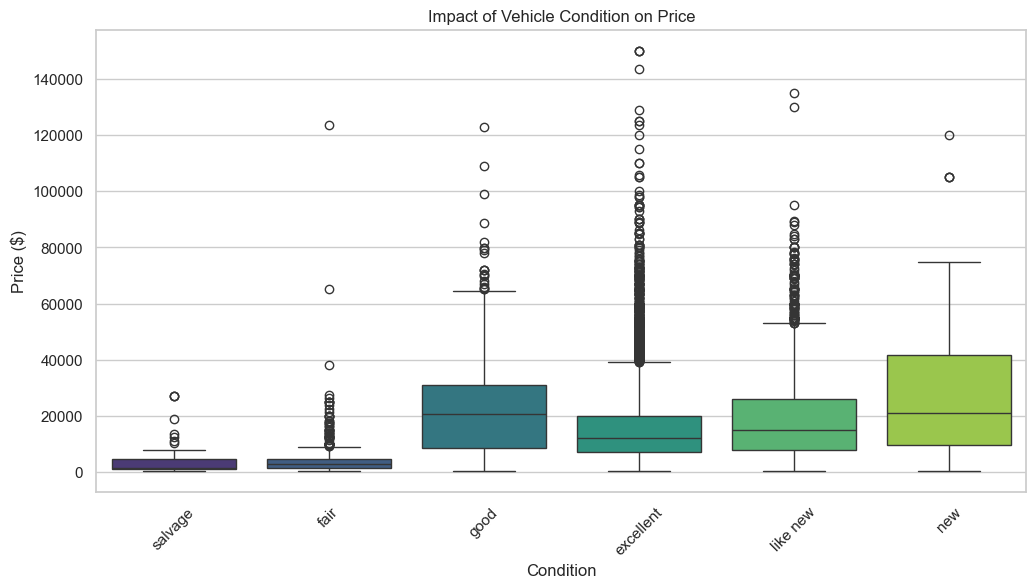

In [11]:
# 3. CATEGORICAL IMPACT: Boxplots for Spread & Outliers
if 'condition' in sample_df.columns:
    plt.figure(figsize=(12,6))
    # Ordering conditions from worst to best logically
    cond_order = ['salvage','fair','good','excellent','like new','new']
    sns.boxplot(x='condition', y='price', data=sample_df, order=cond_order, palette='viridis')
    plt.title('Impact of Vehicle Condition on Price')
    plt.xlabel('Condition')
    plt.ylabel('Price ($)')
    plt.xticks(rotation=45)
    plt.show()


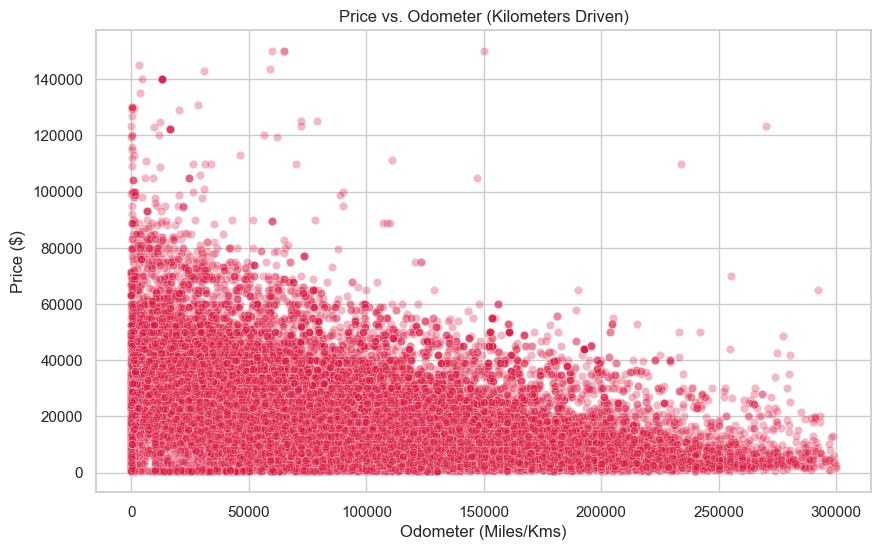

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='odometer', y='price', data=sample_df[sample_df['odometer'] < 300000], 
                alpha=0.3, color='crimson')
plt.title('Price vs. Odometer (Kilometers Driven)')
plt.xlabel('Odometer (Miles/Kms)')
plt.ylabel('Price ($)')
plt.show()


In [13]:
print("Starting Smart Imputation Pipeline...\n")

df_cleaned = df_cleaned.dropna(subset=['year', 'manufacturer'])

df_cleaned['year'] = df_cleaned['year'].astype('float32')
df_cleaned['odometer'] = df_cleaned['odometer'].astype('float32')

print("Imputing 'odometer' using 'year' groupings...")

df_cleaned['odometer'] = df_cleaned['odometer'].fillna(
    df_cleaned.groupby('year')['odometer'].transform('median')
)

df_cleaned['odometer'] = df_cleaned['odometer'].fillna(df_cleaned['odometer'].median())


Starting Smart Imputation Pipeline...

Imputing 'odometer' using 'year' groupings...


In [14]:
display(df_cleaned['type'].cat.categories)


Index(['SUV', 'bus', 'convertible', 'coupe', 'hatchback', 'mini-van',
       'offroad', 'other', 'pickup', 'sedan', 'truck', 'van', 'wagon'],
      dtype='object')

In [15]:
categorical_missing_cols = ['size', 'condition', 'cylinders', 'drive', 'paint_color', 'type']

print(f"Assigning 'unknown' category to high-missing columns...")
for col in categorical_missing_cols:
    if 'unknown' not in df_cleaned[col].cat.categories:
        df_cleaned[col] = df_cleaned[col].cat.add_categories('unknown')
    df_cleaned[col] = df_cleaned[col].fillna('unknown')


# Fill remaining minor categoricals with Mode (Most Frequent)
minor_cats = ['fuel', 'title_status', 'transmission']
for col in minor_cats:
    mode_value = df_cleaned[col].mode()[0]
    df_cleaned[col] = df_cleaned[col].fillna(mode_value)


# Final Health Check
print("\n--- Missing Values AFTER Smart Imputation ---")
cols_to_check = ['price', 'year', 'manufacturer', 'odometer', 'condition', 'cylinders', 'size']
print(df_cleaned[cols_to_check].isnull().sum())
print(f"\nRow count ready for Modeling: {df_cleaned.shape[0]}")


Assigning 'unknown' category to high-missing columns...

--- Missing Values AFTER Smart Imputation ---
price           0
year            0
manufacturer    0
odometer        0
condition       0
cylinders       0
size            0
dtype: int64

Row count ready for Modeling: 369015


In [16]:
print("\n Shape of Dataset")
display(df_cleaned.shape)
print("\n Top 5 Columns")
display(df_cleaned.head())
print("\n Info of Data")
display(df_cleaned.info())



 Shape of Dataset


(369015, 19)


 Top 5 Columns


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,lat,long,posting_date
27,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,unknown,unknown,pickup,white,al,32.59375,-85.5,2021-05-04T12:31:18-0500
28,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,unknown,unknown,pickup,blue,al,32.59375,-85.5,2021-05-04T12:31:08-0500
29,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,unknown,unknown,pickup,red,al,32.59375,-85.5,2021-05-04T12:31:25-0500
30,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,unknown,unknown,pickup,red,al,32.59375,-85.5,2021-05-04T10:41:31-0500
31,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,full-size,truck,black,al,32.59375,-85.5,2021-05-03T14:02:03-0500



 Info of Data
<class 'pandas.core.frame.DataFrame'>
Index: 369015 entries, 27 to 426879
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   region        369015 non-null  object  
 1   price         369015 non-null  int64   
 2   year          369015 non-null  float32 
 3   manufacturer  369015 non-null  object  
 4   model         364542 non-null  object  
 5   condition     369015 non-null  category
 6   cylinders     369015 non-null  category
 7   fuel          369015 non-null  category
 8   odometer      369015 non-null  float32 
 9   title_status  369015 non-null  category
 10  transmission  369015 non-null  category
 11  drive         369015 non-null  category
 12  size          369015 non-null  category
 13  type          369015 non-null  category
 14  paint_color   369015 non-null  category
 15  state         369015 non-null  object  
 16  lat           365684 non-null  float16 
 17  long          3656

None

In [17]:
from sklearn.model_selection import KFold

print("Starting Feature Encoding Pipeline...\n")

# Ordinal Encoding (Ranking matters)
cond_map = {'unknown': 0, 'salvage': 1, 'fair': 2, 'good': 3, 'excellent': 4, 'like new': 5, 'new': 6}
cyl_map = {'unknown': 0, 'other': 0, '3 cylinders': 3, '4 cylinders': 4, '5 cylinders': 5, '6 cylinders': 6, '8 cylinders': 8, '10 cylinders': 10, '12 cylinders': 12}
size_map = {'unknown': 0, 'sub-compact': 1, 'compact': 2, 'mid-size': 3, 'full-size': 4}

df_cleaned['condition'] = df_cleaned['condition'].map(cond_map).astype('int8')
df_cleaned['cylinders'] = df_cleaned['cylinders'].map(cyl_map).astype('int8')
df_cleaned['size'] = df_cleaned['size'].map(size_map).astype('int8')
print("Ordinal Encoding done.")


Starting Feature Encoding Pipeline...

Ordinal Encoding done.


In [18]:

# K-FOLD TARGET ENCODING 
high_card_cols = ['manufacturer', 'state', 'region', 'model']
print(f"Applying K-Fold Target Encoding to: {high_card_cols}...")
for col in high_card_cols:
    df_cleaned[f"{col}_encoded"] = np.nan
    df_cleaned[col] = df_cleaned[col].fillna('unknown')

# Single Split: Split the data into 5 parts ONLY ONCE
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(df_cleaned):
    X_train_fold = df_cleaned.iloc[train_idx]
    X_val_fold = df_cleaned.iloc[val_idx]
    
    # Multi-Column Encoding: Process all columns for this specific fold
    for col in high_card_cols:
        fold_means = X_train_fold.groupby(col)['price'].mean()
        
        df_cleaned.iloc[val_idx, df_cleaned.columns.get_loc(f"{col}_encoded")] = X_val_fold[col].map(fold_means)

# Final Cleanup: Handle rare values, drop old columns, and rename
global_mean = df_cleaned['price'].mean()

for col in high_card_cols:
    encoded_name = f"{col}_encoded"
    
    # Fill any NaNs (categories that didn't appear in the training fold)
    df_cleaned[encoded_name] = df_cleaned[encoded_name].fillna(global_mean)
    
    # Swap original for encoded
    df_cleaned = df_cleaned.drop(columns=[col])
    df_cleaned = df_cleaned.rename(columns={encoded_name: col})
    df_cleaned[col] = df_cleaned[col].astype('float32')

print("Encoding complete! Processed all columns in a single 5-fold pass.")


Applying K-Fold Target Encoding to: ['manufacturer', 'state', 'region', 'model']...
Encoding complete! Processed all columns in a single 5-fold pass.


In [19]:
# Drop Noisy/Redundant Columns
cols_to_drop_final = ['lat', 'long', 'posting_date']
df_cleaned = df_cleaned.drop(columns=cols_to_drop_final)


# One-Hot Encoding (For Low Cardinality Nominal features)
ohe_cols = ['fuel', 'title_status', 'transmission', 'drive', 'paint_color', 'type']
df_cleaned = pd.get_dummies(df_cleaned, columns=ohe_cols, drop_first=True, dtype='int8')
print("One-Hot Encoding done for remaining categoricals.")


print("\n--- THE DATASET IS NOW 100% NUMERIC & PRODUCTION READY ---")
print(f"Final Shape: {df_cleaned.shape}")


One-Hot Encoding done for remaining categoricals.

--- THE DATASET IS NOW 100% NUMERIC & PRODUCTION READY ---
Final Shape: (369015, 49)


In [20]:
df_cleaned.head()


,price,year,condition,cylinders,odometer,size,manufacturer,state,region,model,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,title_status_lien,title_status_missing,title_status_parts only,title_status_rebuilt,title_status_salvage,transmission_manual,transmission_other,drive_fwd,drive_rwd,drive_unknown,paint_color_blue,paint_color_brown,paint_color_custom,paint_color_green,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow,paint_color_unknown,type_bus,type_convertible,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon,type_unknown
27,33590,2014.0,3,8,57923.0,0,25267.568359,21187.634766,27818.490234,34840.000000,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
28,22590,2010.0,3,8,71229.0,0,20314.625000,21094.445312,27949.908203,24027.708984,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
29,39590,2020.0,3,8,19160.0,0,20382.128906,21440.855469,27982.000000,34136.683594,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
30,30990,2017.0,3,8,41124.0,0,17414.039062,21316.886719,27741.681641,34674.421875,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
31,15000,2013.0,4,6,128000.0,4,21269.656250,21187.634766,27818.490234,21970.345703,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

print("Data Splitting & Feature Scaling...\n")

# Separate Features (X) and Target (y)
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData successfully split!")
print(f"Training Set: {X_train.shape[0]} rows")
print(f"Testing Set: {X_test.shape[0]} rows")


Data Splitting & Feature Scaling...

Features shape (X): (369015, 48)
Target shape (y): (369015,)

Data successfully split!
Training Set: 295212 rows
Testing Set: 73803 rows


In [22]:
# Feature Scaling (Using RobustScaler to handle remaining hidden outliers)
print("\nApplying RobustScaler to features...")

scaler = RobustScaler()

# Fit on training data ONLY to prevent Data Leakage, then transform
X_train_scaled_array = scaler.fit_transform(X_train)

# ONLY transform the test data
X_test_scaled_array = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames to keep column names (helps in Feature Importance later)
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test.columns, index=X_test.index)

print("Scaling complete. Features are now centered and scaled.")
display(X_train_scaled.head())



Applying RobustScaler to features...
Scaling complete. Features are now centered and scaled.


,year,condition,cylinders,odometer,size,manufacturer,state,region,model,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,title_status_lien,title_status_missing,title_status_parts only,title_status_rebuilt,title_status_salvage,transmission_manual,transmission_other,drive_fwd,drive_rwd,drive_unknown,paint_color_blue,paint_color_brown,paint_color_custom,paint_color_green,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow,paint_color_unknown,type_bus,type_convertible,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon,type_unknown
103734,0.666667,-0.75,-0.666667,0.125024,0.0,-0.499989,0.036819,0.435593,0.415214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
109302,-0.666667,-0.75,0.333333,-0.176461,0.0,0.153679,0.036819,0.180444,-0.503286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
199309,-1.111111,0.25,0.000000,1.060638,0.0,-0.499989,-0.824853,-1.202951,-0.547277,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
42025,0.333333,0.00,-0.666667,-0.741743,0.0,-0.843362,-0.001251,-0.087464,0.537184,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
24854,-0.666667,-0.75,-0.666667,0.848473,0.0,0.153679,-0.001251,0.019601,0.401949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [23]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# THE UNIVERSAL EVALUATION ENGINE
def evaluate_model(model_name, y_true, y_pred, X_features):
    """Calculates all essential regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Adj R2 Score
    n = X_features.shape[0]
    p = X_features.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    print(f"--- {model_name} Performance ---")
    print(f"MAE:        ${mae:,.2f}")
    print(f"RMSE:       ${rmse:,.2f}")
    print(f"R-Squared:  {r2:.4f}")
    print(f"Adj R-Sq:   {adj_r2:.4f}\n")
    
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Adj_R2': adj_r2}
    
results_log = []


In [24]:
from sklearn.preprocessing import PolynomialFeatures
# Multiple Linear Regression
print("Training Baseline Multiple Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

results_log.append(evaluate_model("Multiple Linear Regression", y_test, y_pred_lr, X_test_scaled))

# NON-LINEAR TRANSFORM: Polynomial Regression
print("Training Polynomial Regression (Degree 2 on Year & Odometer)...")
poly_features = ['year', 'odometer']
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_subset = poly.fit_transform(X_train_scaled[poly_features])
X_test_poly_subset = poly.transform(X_test_scaled[poly_features])
poly_lr = LinearRegression()
poly_lr.fit(X_train_poly_subset, y_train)
y_pred_poly = poly_lr.predict(X_test_poly_subset)

results_log.append(evaluate_model("Polynomial Regression (Subset)", y_test, y_pred_poly, X_test_poly_subset))


Training Baseline Multiple Linear Regression...
--- Multiple Linear Regression Performance ---
MAE:        $5,567.16
RMSE:       $8,953.50
R-Squared:  0.6226
Adj R-Sq:   0.6223

Training Polynomial Regression (Degree 2 on Year & Odometer)...
--- Polynomial Regression (Subset) Performance ---
MAE:        $11,454.33
RMSE:       $14,572.52
R-Squared:  0.0002
Adj R-Sq:   0.0002



In [25]:
# REGULARIZATION: Ridge Regression (L2 Penalty)
print("Training Ridge Regression (L2)...")
# np.logspace(-3, 3, 100) generates 100 values from 0.001 to 1000
alphas_to_test = np.logspace(-3, 3, 100)
ridge_cv_model = RidgeCV(alphas=alphas_to_test, cv=5)
ridge_cv_model.fit(X_train_scaled, y_train)
print(f"Best Alpha found for Ridge: {ridge_cv_model.alpha_:.4f}")
results_log.append(evaluate_model("Ridge Regression (L2)", y_test, ridge_cv_model.predict(X_test_scaled), X_test_scaled))


Training Ridge Regression (L2)...
Best Alpha found for Ridge: 17.4753
--- Ridge Regression (L2) Performance ---
MAE:        $5,556.73
RMSE:       $8,946.82
R-Squared:  0.6232
Adj R-Sq:   0.6229



In [26]:
print("Training Lasso Regression (Finding best alpha via CV)...")
# Using less folds (cv=3) or default alphas here to save time, as L1 is computationally heavier
lasso_cv_model = LassoCV(cv=3, random_state=42, max_iter=10000)
lasso_cv_model.fit(X_train_scaled, y_train)
print(f"Best Alpha found for Lasso: {lasso_cv_model.alpha_:.4f}")
results_log.append(evaluate_model("Lasso Regression (L1)", y_test, lasso_cv_model.predict(X_test_scaled), X_test_scaled))

# Feature Selection Check
zero_features = np.sum(lasso_cv_model.coef_ == 0)
print(f"Lasso (with optimal alpha) dropped {zero_features} completely useless features!\n")


Training Lasso Regression (Finding best alpha via CV)...
Best Alpha found for Lasso: 8.0493
--- Lasso Regression (L1) Performance ---
MAE:        $5,550.25
RMSE:       $8,951.48
R-Squared:  0.6228
Adj R-Sq:   0.6225

Lasso (with optimal alpha) dropped 9 completely useless features!



In [27]:
# ELASTIC NET (L1 + L2 Hybrid)
print("Training Elastic Net CV (L1 + L2)...")
elastic_net_model = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=3, n_alphas=100, random_state=42, max_iter=10000, n_jobs=-1)
elastic_net_model.fit(X_train_scaled, y_train)

print(f"Best L1 Ratio selected by CV: {elastic_net_model.l1_ratio_}")
results_log.append(evaluate_model("Elastic Net", y_test, elastic_net_model.predict(X_test_scaled), X_test_scaled))


Training Elastic Net CV (L1 + L2)...
Best L1 Ratio selected by CV: 1.0
--- Elastic Net Performance ---
MAE:        $5,550.25
RMSE:       $8,951.48
R-Squared:  0.6228
Adj R-Sq:   0.6225



In [28]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print("Starting The Non-Linear & Ensemble Heavyweights...\n")

# DISTANCE-BASED: K-Nearest Neighbors (KNN)
# Math: Finds the 'k' most similar cars in the training set and averages their price.
print("Training KNN Regressor...")
# Using n_jobs=-1 to use all CPU cores because distance calculation is heavy
knn_model = KNeighborsRegressor(n_neighbors=7, n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

results_log.append(evaluate_model("KNN Regressor", y_test, y_pred_knn, X_test_scaled))


# ENSEMBLE (BAGGING): Random Forest Regressor
# Math: Builds 100 independent decision trees and averages their predictions.
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

results_log.append(evaluate_model("Random Forest", y_test, y_pred_rf, X_test_scaled))


# ENSEMBLE (BOOSTING): XGBoost Regressor
# Math: Builds trees sequentially. Each new tree focuses ONLY on the mistakes (residuals) of the previous tree.
print("Training XGBoost Regressor (Sequential error correction)...")
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=8, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

results_log.append(evaluate_model("XGBoost", y_test, y_pred_xgb, X_test_scaled))


Starting The Non-Linear & Ensemble Heavyweights...

Training KNN Regressor...
--- KNN Regressor Performance ---
MAE:        $3,364.35
RMSE:       $6,067.46
R-Squared:  0.8267
Adj R-Sq:   0.8266

Training Random Forest Regressor...
--- Random Forest Performance ---
MAE:        $2,962.13
RMSE:       $5,458.65
R-Squared:  0.8597
Adj R-Sq:   0.8596

Training XGBoost Regressor (Sequential error correction)...
--- XGBoost Performance ---
MAE:        $3,003.80
RMSE:       $5,503.74
R-Squared:  0.8574
Adj R-Sq:   0.8573



In [29]:

# THE FINAL SHOWDOWN (Leaderboard Generation)
print("FINAL REGRESSION LEADERBOARD (Sorted by Adj R-Sq)")

results_df = pd.DataFrame(results_log)
# Sort by Adjusted R-Squared descending (Higher is better)
results_df = results_df.sort_values(by='Adj_R2', ascending=False).reset_index(drop=True)

# Format for pretty printing
format_mapping = {'MAE': '${:,.2f}', 'RMSE': '${:,.2f}', 'R2': '{:.4f}', 'Adj_R2': '{:.4f}'}
display(results_df.style.format(format_mapping)\
        .background_gradient(cmap='Greens', subset=['R2', 'Adj_R2'])\
        .background_gradient(cmap='Reds_r', subset=['MAE', 'RMSE'])) # Reds_r means lower error = lighter color


FINAL REGRESSION LEADERBOARD (Sorted by Adj R-Sq)


,Model,MAE,RMSE,R2,Adj_R2
0,Random Forest,"$2,962.13","$5,458.65",0.8597,0.8596
1,XGBoost,"$3,003.80","$5,503.74",0.8574,0.8573
2,KNN Regressor,"$3,364.35","$6,067.46",0.8267,0.8266
3,Ridge Regression (L2),"$5,556.73","$8,946.82",0.6232,0.6229
4,Lasso Regression (L1),"$5,550.25","$8,951.48",0.6228,0.6225
5,Elastic Net,"$5,550.25","$8,951.48",0.6228,0.6225
6,Multiple Linear Regression,"$5,567.16","$8,953.50",0.6226,0.6223
7,Polynomial Regression (Subset),"$11,454.33","$14,572.52",0.0002,0.0002


Extracting the Brain of the Random Forest (Feature Importance)...



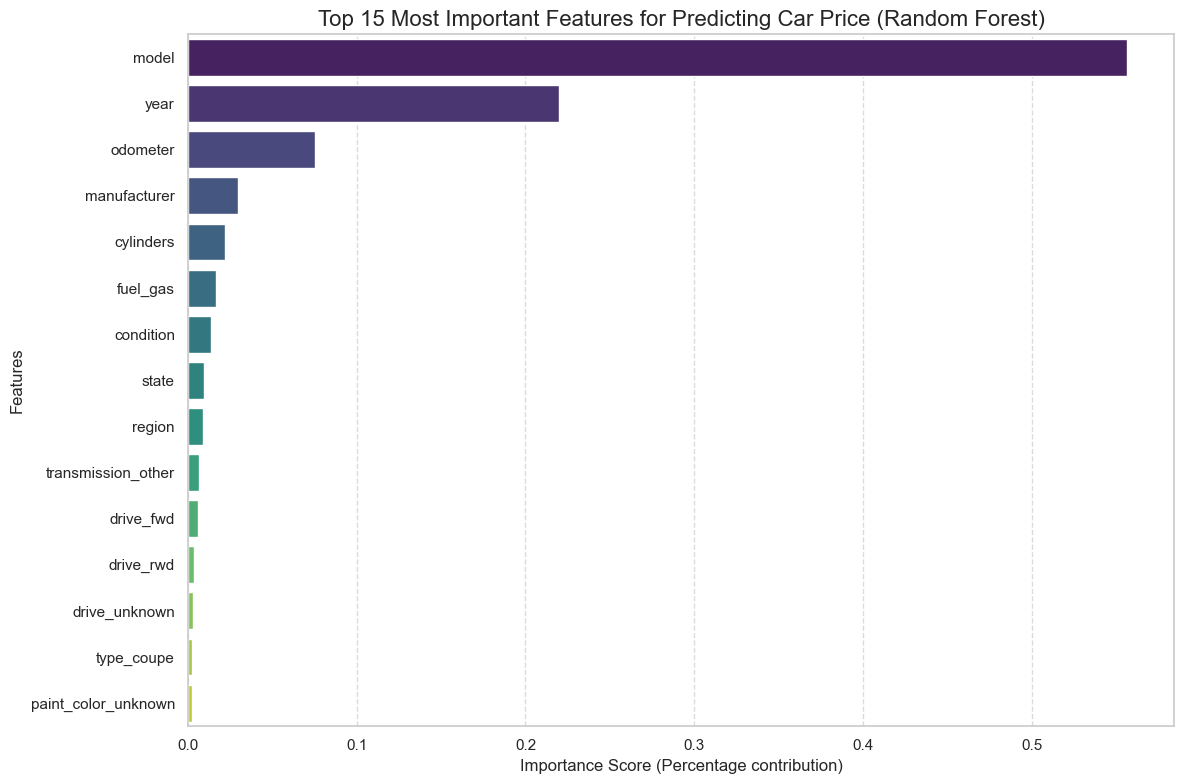

Top 3 Price Drivers according to the model:
1. model (55.7%)
2. year (22.0%)
3. odometer (7.5%)


In [30]:
print("Extracting the Brain of the Random Forest (Feature Importance)...\n")

# Get feature importances from our winning Random Forest model
importances = rf_model.feature_importances_
feature_names = X_train_scaled.columns

# Create a DataFrame for easy sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort values in descending order and grab the Top 15
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plotting the Feature Importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title('Top 15 Most Important Features for Predicting Car Price (Random Forest)', fontsize=16)
plt.xlabel('Importance Score (Percentage contribution)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the top 3 drivers
print("Top 3 Price Drivers according to the model:")
for i in range(3):
    print(f"{i+1}. {importance_df.iloc[i]['Feature']} ({importance_df.iloc[i]['Importance']*100:.1f}%)")


In [31]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
import time

print("Starting Hyperparameter Tuning using XGBoost. But why not Random Forest? because it can be better and it's fast in hyperparameter tuning...\n")

# Define the Parameter Grid
param_dist = {
    'n_estimators': stats.randint(200, 500),         # Number of trees
    'learning_rate': stats.uniform(0.01, 0.15),      # Step size
    'max_depth': stats.randint(6, 12),               # Maximum depth of a tree
    'subsample': stats.uniform(0.7, 0.3),            # Row sampling (prevents overfitting)
    'colsample_bytree': stats.uniform(0.7, 0.3)      # Column sampling
}

# Initialize the Base Model
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# Setup RandomizedSearchCV
# n_iter=5 means it will randomly try 5 different combinations from the grid
# cv=3 means 3-Fold Cross Validation for each combination. Total 15 model trainings
print("Initiating RandomizedSearchCV...this will take a few minutes!")
start_time = time.time()

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=5,  # Keeping it at 5 for faster results. In production on cloud, we do 50+
    cv=3,
    scoring='neg_root_mean_squared_error', # We want to minimize RMSE
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train!
random_search.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"\nTuning Complete! Time taken: {(end_time - start_time)/60:.2f} minutes")

# Extract the Ultimate Champion Model
best_xgb_model = random_search.best_estimator_

print("\nTHE WINNING HYPERPARAMETERS")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

# Final Evaluation
print("\n--- FINAL OPTIMIZED MODEL PERFORMANCE ON UNSEEN TEST DATA ---")
# Evaluate our winning model
final_pred = best_xgb_model.predict(X_test_scaled)
evaluate_model("Tuned XGBoost Master", y_test, final_pred, X_test_scaled)


Starting Hyperparameter Tuning using XGBoost. But why not Random Forest? because it can be better and it's fast in hyperparameter tuning...

Initiating RandomizedSearchCV...this will take a few minutes!
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.15260714596148742, max_depth=8, n_estimators=271, subsample=0.8795975452591109; total time=  13.1s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.15260714596148742, max_depth=8, n_estimators=271, subsample=0.8795975452591109; total time=  13.1s
[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.15260714596148742, max_depth=8, n_estimators=271, subsample=0.8795975452591109; total time=  13.4s
[CV] END colsample_bytree=0.7468055921327309, learning_rate=0.0333991780504304, max_depth=8, n_estimators=287, subsample=0.8001125833417065; total time=  15.3s
[CV] END colsample_bytree=0.7468055921327309, learning_rate=0.0333991780504304, max_depth=8, n

{'Model': 'Tuned XGBoost Master',
 'MAE': 2651.679931640625,
 'RMSE': np.float64(4993.932919052878),
 'R2': 0.8825889825820923,
 'Adj_R2': 0.8825125700643162}

In [32]:
import joblib
import os

print("Starting Model Serialization (Saving for Production)...\n")

# Create a folder to save models if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the Tuned XGBoost Master Model
joblib.dump(best_xgb_model, '../models/xgboost_pricing_master.pkl')
print("XGBoost Model saved successfully as 'xgboost_pricing_master.pkl'")

# Save the RobustScaler 
# CRITICAL: We need this to scale new user inputs exactly how training data was scaled
joblib.dump(scaler, '../models/robust_scaler.pkl')
print("Scaler saved successfully as 'robust_scaler.pkl'")

# Save the Exact Column Order
# When a user submits data via an API, the One-Hot Encoded columns must match this exact order
training_columns = X_train_scaled.columns.tolist()
joblib.dump(training_columns, '../models/training_columns.pkl')
print("Feature columns schema saved successfully as 'training_columns.pkl'")

print("\n MISSION ACCOMPLISHED! The Dynamic Pricing Engine is ready for deployment. 🎉")


Starting Model Serialization (Saving for Production)...

XGBoost Model saved successfully as 'xgboost_pricing_master.pkl'
Scaler saved successfully as 'robust_scaler.pkl'
Feature columns schema saved successfully as 'training_columns.pkl'

 MISSION ACCOMPLISHED! The Dynamic Pricing Engine is ready for deployment. 🎉


In [33]:
print("Exporting processed data for Statistical Testing...")
os.makedirs('../data/processed', exist_ok=True)

# Save memory-optimized dataframes exactly as they are
df_cleaned.to_pickle('../data/processed/df_cleaned.pkl')
X_train_scaled.to_pickle('../data/processed/X_train_scaled.pkl')

# y_train is a Series, converting to frame for safe saving
y_train.to_frame().to_pickle('../data/processed/y_train.pkl')

print("Data successfully saved to 'data/processed/' folder!")


Exporting processed data for Statistical Testing...
Data successfully saved to 'data/processed/' folder!
